In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/simple_banking_dataset.csv')

# Data Analysis

In [ ]:
df.head()

,Customer_ID,Age,Gender,Account_Balance,Monthly_Income,Credit_Score,Loan_Amount,Loan_Tenure_Years,Num_of_Transactions_Monthly,Has_Credit_Card,Loan_Default
0,CUST1000,59,Female,42296.40,80025.04,445,361774.35,9,111,No,0
1,CUST1001,49,Male,156320.02,66028.32,410,179683.86,6,49,No,1
2,CUST1002,35,Male,99500.96,110186.39,527,361951.61,16,62,No,0
3,CUST1003,63,Male,137895.05,48577.76,410,112685.62,13,119,Yes,0
4,CUST1004,28,Female,245213.54,59584.09,769,141109.59,23,35,Yes,1


In [ ]:
df.tail()

,Customer_ID,Age,Gender,Account_Balance,Monthly_Income,Credit_Score,Loan_Amount,Loan_Tenure_Years,Num_of_Transactions_Monthly,Has_Credit_Card,Loan_Default
195,CUST1195,22,Male,122159.17,46484.22,685,755413.19,9,85,Yes,0
196,CUST1196,22,Male,454308.38,61295.13,509,379371.37,3,76,Yes,1
197,CUST1197,48,Male,297984.93,78985.94,774,689634.12,5,25,Yes,0
198,CUST1198,43,Female,178358.03,62939.08,717,675639.52,6,22,Yes,1
199,CUST1199,57,Male,355549.69,102591.08,646,255280.38,4,98,No,0


In [ ]:
df.shape

(200, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  200 non-null    object 
 1   Age                          200 non-null    int64  
 2   Gender                       200 non-null    object 
 3   Account_Balance              200 non-null    float64
 4   Monthly_Income               200 non-null    float64
 5   Credit_Score                 200 non-null    int64  
 6   Loan_Amount                  200 non-null    float64
 7   Loan_Tenure_Years            200 non-null    int64  
 8   Num_of_Transactions_Monthly  200 non-null    int64  
 9   Has_Credit_Card              200 non-null    object 
 10  Loan_Default                 200 non-null    int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 17.3+ KB


In [ ]:
df.describe()

,Age,Account_Balance,Monthly_Income,Credit_Score,Loan_Amount,Loan_Tenure_Years,Num_of_Transactions_Monthly,Loan_Default
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,43.220000,247152.070150,80426.466800,597.655000,379729.427150,11.645000,59.89000,0.245000
std,13.271483,144794.433048,37621.553698,171.770959,233220.033467,7.321681,32.69853,0.431166
min,21.000000,7566.510000,15350.330000,300.000000,8796.660000,0.000000,5.00000,0.000000
25%,31.750000,123547.417500,49223.735000,443.500000,170945.342500,5.000000,31.00000,0.000000
50%,44.000000,244530.705000,79648.860000,597.500000,370142.315000,12.000000,62.00000,0.000000
75%,55.000000,360635.800000,113035.632500,734.250000,573392.515000,17.000000,86.25000,0.000000
max,64.000000,497985.960000,149437.240000,897.000000,797499.400000,24.000000,119.00000,1.000000


**PROBLEM STATEMENT**

To build a data-driven model that predicts whether a bank customer is likely to default on a loan, using demographic, financial, and transactional information.

**Target Column**- Loan_Default

**Supervised Classification Problem**- As target column is discrete numerical value which is binary categorical.

Target column already encoded.

Cardinality Check

In [ ]:
df['Loan_Default'].value_counts()

,count
Loan_Default,
0,151
1,49


Imbalance is there.

Null Value Checking

In [ ]:
df.isna().sum()

,0
Customer_ID,0
Age,0
Gender,0
Account_Balance,0
Monthly_Income,0
Credit_Score,0
Loan_Amount,0
Loan_Tenure_Years,0
Num_of_Transactions_Monthly,0
Has_Credit_Card,0


No null values and hence other visualizations not needed.

Outlier Detection

<Axes: xlabel='Age'>

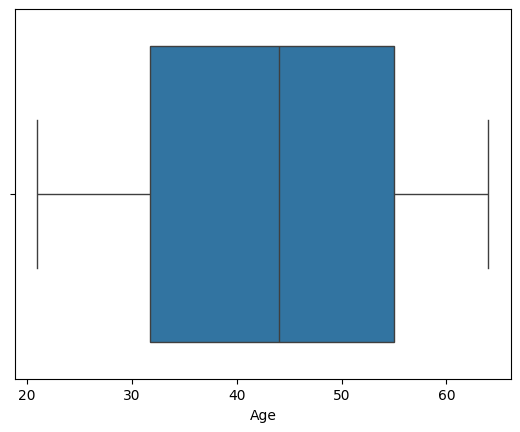

In [ ]:
sns.boxplot(x=df['Age'])

<Axes: xlabel='Account_Balance'>

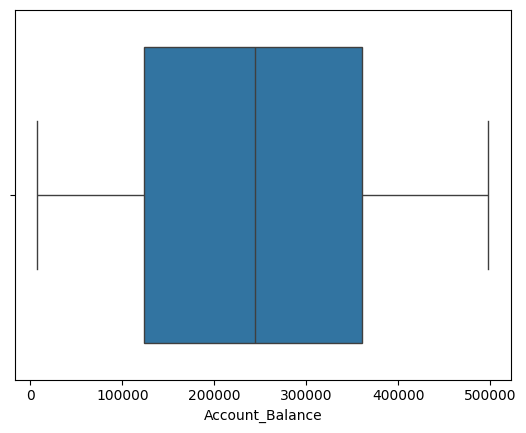

In [ ]:
sns.boxplot(x=df['Account_Balance'])

<Axes: xlabel='Monthly_Income'>

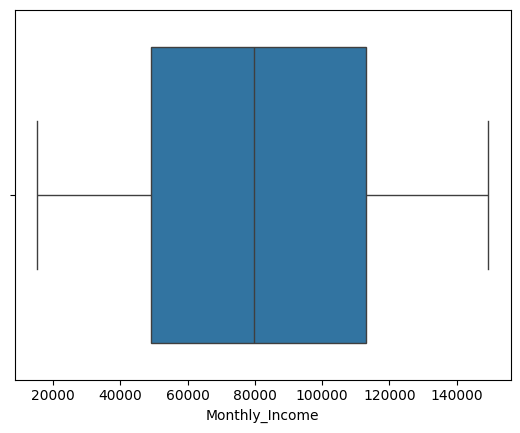

In [ ]:
sns.boxplot(x=df['Monthly_Income'])

<Axes: xlabel='Loan_Amount'>

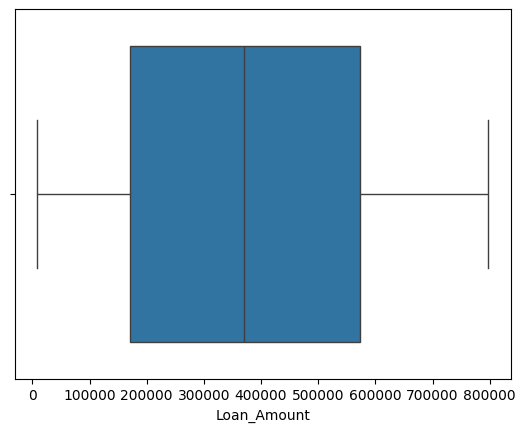

In [ ]:
sns.boxplot(x=df['Loan_Amount'])

<Axes: xlabel='Loan_Tenure_Years'>

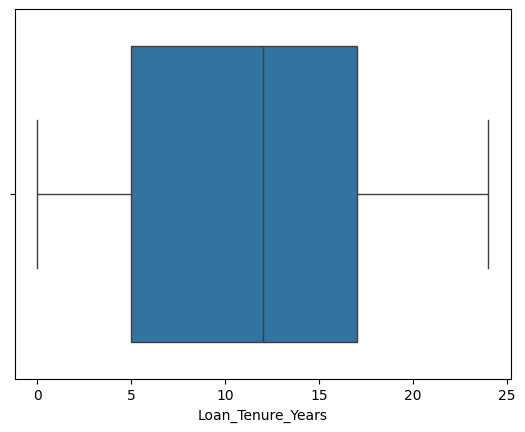

In [ ]:
sns.boxplot(x=df['Loan_Tenure_Years'])

<Axes: xlabel='Num_of_Transactions_Monthly'>

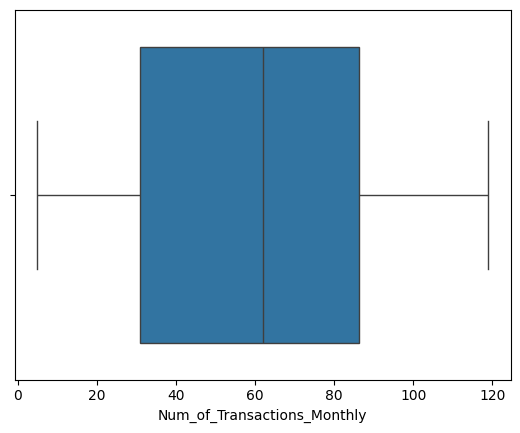

In [ ]:
sns.boxplot(x=df['Num_of_Transactions_Monthly'])

No outliers.

# Feature Engineering

In [ ]:
X= df.drop('Loan_Default',axis=1)
y= df['Loan_Default']

In [ ]:
categorical_cols=["Gender","Has_Credit_Card"]
numerical_cols=['Age','Account_Balance','Monthly_Income','Credit_Score','Loan_Amount','Loan_Tenure_Years','Num_of_Transactions_Monthly']

The categorical_cols are nominal binary columns and since using inside pipeline encoding using OneHotEncoder.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor= ColumnTransformer(transformers=[
    ('num',StandardScaler(),numerical_cols),
    ('cat',OneHotEncoder(),categorical_cols)
])

# Model Selection

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(class_weight='balanced',random_state=42))
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Account_Balance',
                                                   'Monthly_Income',
                                                   'Credit_Score',
                                                   'Loan_Amount',
                                                   'Loan_Tenure_Years',
                                                   'Num_of_Transactions_Monthly']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Gender',
                                                   'Has_Credit_Card'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [ ]:
y_pred=pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

metric_df=pd.DataFrame({
    'Model':['Logistic Regression'],
    'Accuracy':[accuracy_score(y_test,y_pred)],
    'Precision':[precision_score(y_test,y_pred)],
    'Recall':[recall_score(y_test,y_pred)],
    'F1 score':[f1_score(y_test,y_pred)],
    'ROC AUC':[roc_auc_score(y_test,y_pred)]
})

metric_df

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC
0,Logistic Regression,0.55,0.157895,0.6,0.25,0.571429


In [ ]:
pipeline2=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",KNeighborsClassifier(n_neighbors=5))
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
pipeline2.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Account_Balance',
                                                   'Monthly_Income',
                                                   'Credit_Score',
                                                   'Loan_Amount',
                                                   'Loan_Tenure_Years',
                                                   'Num_of_Transactions_Monthly']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Gender',
                                                   'Has_Credit_Card'])])),
                ('classifier', KNeighborsClassifier())])

In [ ]:
y_pred2=pipeline2.predict(X_test)

In [ ]:
metric_df.loc[1]=[
    'KNN',
    accuracy_score(y_test,y_pred2),
    precision_score(y_test,y_pred2),
    recall_score(y_test,y_pred2),
    f1_score(y_test,y_pred2),
    roc_auc_score(y_test,y_pred2)]


metric_df

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC
0,Logistic Regression,0.550,0.157895,0.6,0.250000,0.571429
1,KNN,0.825,0.333333,0.4,0.363636,0.642857


In [ ]:
pipeline3=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",DecisionTreeClassifier(random_state=42))
])

In [ ]:
pipeline3.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Account_Balance',
                                                   'Monthly_Income',
                                                   'Credit_Score',
                                                   'Loan_Amount',
                                                   'Loan_Tenure_Years',
                                                   'Num_of_Transactions_Monthly']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Gender',
                                                   'Has_Credit_Card'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
y_pred3=pipeline3.predict(X_test)

In [ ]:
metric_df.loc[2]=[
    'Decision Tree',
    accuracy_score(y_test,y_pred3),
    precision_score(y_test,y_pred3),
    recall_score(y_test,y_pred3),
    f1_score(y_test,y_pred3),
    roc_auc_score(y_test,y_pred3)]


metric_df

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC
0,Logistic Regression,0.550,0.157895,0.6,0.250000,0.571429
1,KNN,0.825,0.333333,0.4,0.363636,0.642857
2,Decision Tree,0.600,0.133333,0.4,0.200000,0.514286


In [ ]:
pipeline4=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(random_state=42))
])

In [ ]:
pipeline4.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Account_Balance',
                                                   'Monthly_Income',
                                                   'Credit_Score',
                                                   'Loan_Amount',
                                                   'Loan_Tenure_Years',
                                                   'Num_of_Transactions_Monthly']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Gender',
                                                   'Has_Credit_Card'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred4=pipeline4.predict(X_test)

In [ ]:
metric_df.loc[3]=[
    'Random Forest',
    accuracy_score(y_test,y_pred4),
    precision_score(y_test,y_pred4),
    recall_score(y_test,y_pred4),
    f1_score(y_test,y_pred4),
    roc_auc_score(y_test,y_pred4)]


metric_df

,Model,Accuracy,Precision,Recall,F1 score,ROC AUC
0,Logistic Regression,0.550,0.157895,0.6,0.250000,0.571429
1,KNN,0.825,0.333333,0.4,0.363636,0.642857
2,Decision Tree,0.600,0.133333,0.4,0.200000,0.514286
3,Random Forest,0.775,0.000000,0.0,0.000000,0.442857


# Inferences

**Observations:**

**KNN** has the highest accuracy (0.825), but:

Precision = 0.33 → only 1/3 of predicted positives are correct

Recall = 0.4 → detects 40% of defaulters

F1 = 0.36 → moderate balance

**Logistic Regression** has low accuracy (0.55), but:

Recall = 0.6 → detects 60% of defaulters

F1 = 0.25 → very low precision reduces F1

**Random Forest** is bad here → predicts all majority class (Recall=0, Precision=0)

“Although KNN has higher accuracy and F1-score, Logistic Regression achieves higher recall for defaulters (60%), which is critical for a bank because missing a defaulter is more costly. Therefore, I would prefer Logistic Regression in this business scenario. For KNN, recall could be improved with resampling or threshold adjustment.”

In [ ]:
import pickle
pickle_model_path="banking.pkl"
with open(pickle_model_path,"wb") as f:
  pickle.dump(pipeline3,f)